# IMU Sensor Logger Tutorial: Explore → Synchronize → Label → Window

This notebook uses the Sensor Logger recording `2026-10-01_12-44-05.zip`.

We will:

1. inspect the exported sensor files and metadata,
2. plot accelerometer and gyroscope data,
3. deliberately try the **wrong** annotation timestamp overlay,
4. use the three table taps to estimate the clock offset,
5. shift annotations onto the sensor clock,
6. turn annotation events into labeled time regions,
7. combine accelerometer + gyroscope into a regular 6-channel IMU signal,
8. cut the recording into fixed windows,
9. compute simple hand-engineered features ready for scikit-learn.

Along the way there are short **Your turn** cells. The point is not just to get a working pipeline, but to understand what each transformation does.

> **Important:** the three repeated `Standing` annotations immediately after `Taps` were used as synchronization taps. They are **not** treated as behavioral ground-truth segments later in the notebook.


## 0. Setup

Put the ZIP file in the same folder as this notebook.

The code below extracts it into a temporary working folder. It does not modify the original ZIP.


In [1]:
from pathlib import Path
import itertools
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

ZIP_PATH = Path("2026-10-01_12-44-05.zip")
EXTRACT_DIR = Path("sensorlogger_2026-10-01_12-44-05")

assert ZIP_PATH.exists(), f"Could not find {ZIP_PATH.resolve()}"

EXTRACT_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(EXTRACT_DIR)

sorted(p.name for p in EXTRACT_DIR.glob("*.csv"))


['Accelerometer.csv',
 'AccelerometerUncalibrated.csv',
 'Annotation.csv',
 'Barometer.csv',
 'Compass.csv',
 'Gravity.csv',
 'Gyroscope.csv',
 'GyroscopeUncalibrated.csv',
 'Magnetometer.csv',
 'MagnetometerUncalibrated.csv',
 'Metadata.csv',
 'Orientation.csv',
 'TotalAcceleration.csv']

## 1. Inspect the metadata and annotations

Before plotting anything, inspect what the logger says it recorded.

Pay attention to:

- requested sample interval in `sampleRateMs`,
- recording time and timezone,
- which sensor streams are present,
- the annotation labels and their raw timestamps.


In [2]:
metadata = pd.read_csv(EXTRACT_DIR / "Metadata.csv")
annotations = pd.read_csv(EXTRACT_DIR / "Annotation.csv")

display(metadata.T)
display(annotations)


,0
version,3
device name,SM-S916U
recording epoch time,1790858645299
recording time,2026-10-01_12-44-05
recording timezone,America/New_York
platform,android
appVersion,1.67
device id,2299c670-e9f2-49da-b7fb-631158375586
sensors,Accelerometer|Gravity|Gyroscope|Orientation|Ma...
sampleRateMs,10|10|10|10|10|10|0||10|10|10|10


,time,seconds_elapsed,text,millisecond_press_duration
0,297484205250000,-1.790561e+09,Taps,50
1,297505584250000,-1.790561e+09,Standing,127
2,297507383250000,-1.790561e+09,Standing,83
3,297509323250000,-1.790561e+09,Standing,67
4,297530301250000,-1.790561e+09,Walking,75
5,297570995250000,-1.790561e+09,Standing,68
6,297606305250000,-1.790561e+09,Walking,59
7,297635298250000,-1.790561e+09,StairsDown,100
8,297677335250000,-1.790561e+09,Walking,86
9,297753044250000,-1.790561e+09,Standing,66


### Your turn

Look at the annotation table.

1. Which rows appear to be the three synchronization taps?
2. Which row is the first **real activity** annotation?
3. Why would it be dangerous to automatically assume that every annotation in the file is a behavioral label?

Write your answers here before moving on.


## 2. Load accelerometer and gyroscope data

Sensor Logger gives us several acceleration-related streams. For this tutorial we use:

- `Accelerometer.csv`: approximately gravity-removed / dynamic acceleration,
- `Gyroscope.csv`: angular velocity,
- `TotalAcceleration.csv`: acceleration including gravity.

We will eventually build a 6-channel IMU signal:

`ax, ay, az, gx, gy, gz`


In [3]:
acc = pd.read_csv(EXTRACT_DIR / "Accelerometer.csv")
gyro = pd.read_csv(EXTRACT_DIR / "Gyroscope.csv")
total_acc = pd.read_csv(EXTRACT_DIR / "TotalAcceleration.csv")
baro = pd.read_csv(EXTRACT_DIR / "Barometer.csv")

acc["magnitude"] = np.sqrt(acc["x"]**2 + acc["y"]**2 + acc["z"]**2)
gyro["magnitude"] = np.sqrt(gyro["x"]**2 + gyro["y"]**2 + gyro["z"]**2)
total_acc["magnitude"] = np.sqrt(
    total_acc["x"]**2 + total_acc["y"]**2 + total_acc["z"]**2
)

display(acc.head())
display(gyro.head())


,time,seconds_elapsed,z,y,x,magnitude
0,1790858644682499000,-0.616501,0.000000,0.000000,0.000000,0.000000
1,1790858644701443000,-0.597557,-0.030310,0.031099,0.046278,0.063462
2,1790858644720387000,-0.578613,-0.023931,-0.023861,0.079543,0.086424
3,1790858644739330800,-0.559669,-0.018126,-0.072766,0.081014,0.110393
4,1790858644758274800,-0.540725,0.021524,-0.047287,0.033650,0.061901


,time,seconds_elapsed,z,y,x,magnitude
0,1790858644691971000,-0.607029,0.002443,0.000916,0.000153,0.002614
1,1790858644710915000,-0.588085,0.002443,0.000305,-0.000458,0.002505
2,1790858644729858800,-0.569141,0.003665,0.002138,0.000153,0.004246
3,1790858644748802800,-0.550197,0.003665,0.000916,0.000153,0.003781
4,1790858644767746800,-0.531253,0.010996,-0.003360,0.000153,0.011498


## 3. What sampling rate did we actually get?

The metadata requests a 10 ms sample interval, which would correspond to 100 Hz.

But requested rate and observed rate are not always identical on a phone. Let's estimate the actual rate from the timestamps.


In [4]:
def estimate_fs(df):
    dt = np.diff(df["seconds_elapsed"].to_numpy())
    return 1 / np.median(dt)

for name, df in {
    "Accelerometer": acc,
    "Gyroscope": gyro,
    "TotalAcceleration": total_acc,
    "Barometer": baro,
}.items():
    print(f"{name:18s}: {estimate_fs(df):6.2f} Hz")


Accelerometer     :  52.79 Hz
Gyroscope         :  52.79 Hz
TotalAcceleration :  52.79 Hz
Barometer         :  25.00 Hz


**Observation for this recording:** the IMU streams are closer to ~53 Hz than the requested 100 Hz.

That is useful, not a failure. It gives us a real data-engineering lesson:

> Never assume the sampling rate just because you asked the device for one.

Later we will interpolate onto a regular grid. For a CNN, every window must have the same shape.

### Your turn

Why does interpolating a ~53 Hz recording onto a 100 Hz grid **not** magically create new physical information?


## 4. Plot the raw IMU data

Start by looking at the whole recording. We will plot XYZ and magnitude.

The magnitude is useful because it is less sensitive to phone orientation:

\[
|a| = \sqrt{a_x^2 + a_y^2 + a_z^2}
\]


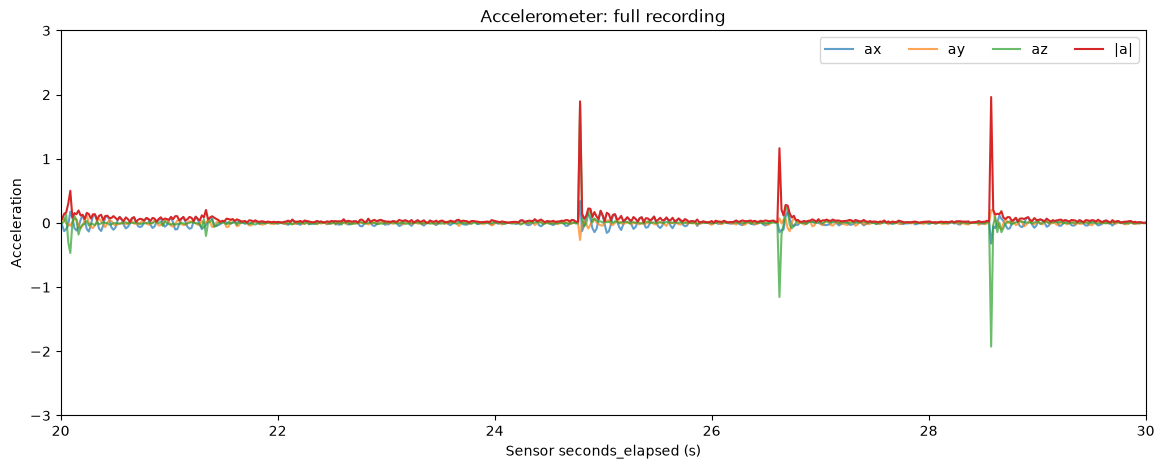

In [ ]:

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(acc["seconds_elapsed"], acc["x"], label="ax", alpha=0.7)
ax.plot(acc["seconds_elapsed"], acc["y"], label="ay", alpha=0.7)
ax.plot(acc["seconds_elapsed"], acc["z"], label="az", alpha=0.7)
ax.plot(acc["seconds_elapsed"], acc["magnitude"], label="|a|", linewidth=1.5)

ax.set_xlabel("Sensor seconds_elapsed (s)")
ax.set_ylabel("Acceleration")
ax.set_title("Accelerometer: full recording")
ax.legend(ncol=4)
#ax.set_xlim([20,30])
#ax.set_ylim([-3, 3])
plt.show()


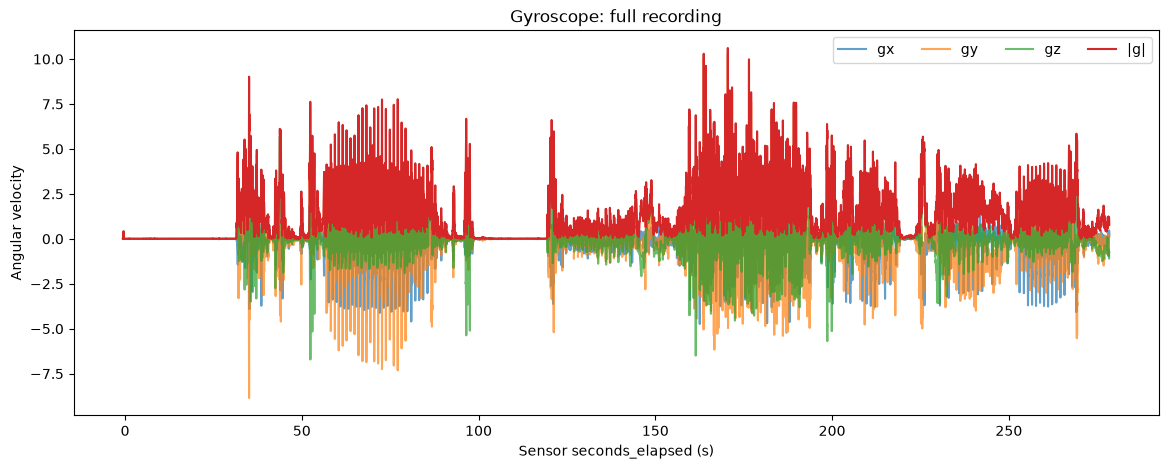

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(gyro["seconds_elapsed"], gyro["x"], label="gx", alpha=0.7)
ax.plot(gyro["seconds_elapsed"], gyro["y"], label="gy", alpha=0.7)
ax.plot(gyro["seconds_elapsed"], gyro["z"], label="gz", alpha=0.7)
ax.plot(gyro["seconds_elapsed"], gyro["magnitude"], label="|g|", linewidth=1.5)

ax.set_xlabel("Sensor seconds_elapsed (s)")
ax.set_ylabel("Angular velocity")
ax.set_title("Gyroscope: full recording")
ax.legend(ncol=4)
plt.show()


### Your turn

Before using the annotations:

- Where does the phone appear quiet?
- Where do you see sustained locomotor activity?
- Can you spot any abrupt transitions?
- Which signal looks easier to interpret, individual axes or magnitude?


## 5. First try: overlay the annotation timestamps **wrong**

This is deliberate.

If all streams used the same clock, `annotations["seconds_elapsed"]` should land somewhere inside the sensor recording.

Let's try it.


In [29]:
print("Sensor time range:")
print(acc["seconds_elapsed"].min(), "to", acc["seconds_elapsed"].max())

print("\nAnnotation seconds_elapsed range:")
print(annotations["seconds_elapsed"].min(), "to", annotations["seconds_elapsed"].max())


Sensor time range:
-0.6165009765625 to 278.4131750488281

Annotation seconds_elapsed range:
-1790561161.09375 to -1790560892.25475


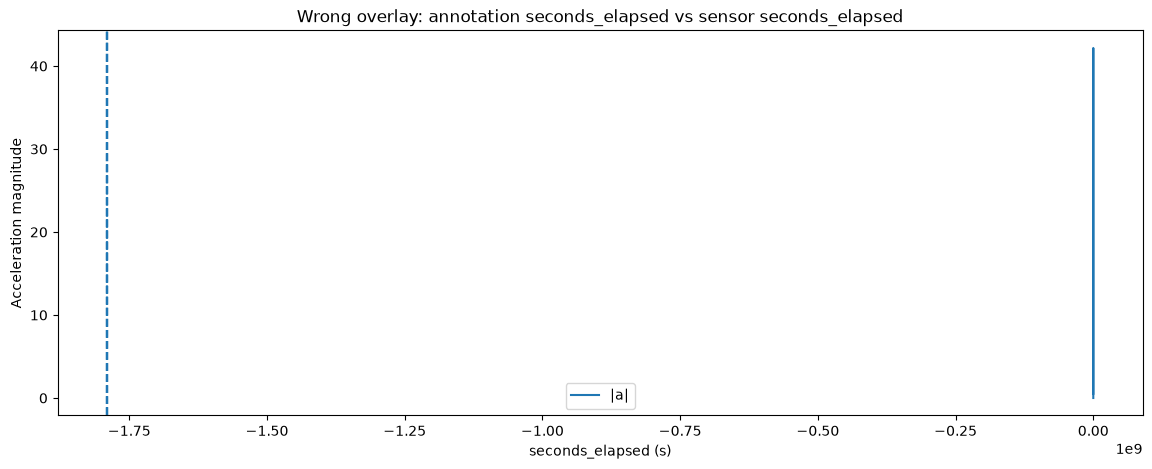

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(acc["seconds_elapsed"], acc["magnitude"], label="|a|")

for _, row in annotations.iterrows():
    ax.axvline(row["seconds_elapsed"], linestyle="--", alpha=0.6)

ax.set_xlabel("seconds_elapsed (s)")
ax.set_ylabel("Acceleration magnitude")
ax.set_title("Wrong overlay: annotation seconds_elapsed vs sensor seconds_elapsed")
ax.legend()
plt.show()


That overlay fails spectacularly because the annotation stream is using a different clock basis from the sensor streams.

For this export, the annotation `time` values are internally consistent with one another, even though they are not on the same absolute clock as the IMU.

So we can preserve **annotation spacing** and solve for a single time shift.


## 6. Put annotations on their own relative time axis

We define the first annotation (`Taps`) as annotation-relative time 0.

This does **not** synchronize it yet. It only preserves the timing between annotations.


In [9]:
annotations = annotations.copy()

annotations["annotation_rel_s"] = (
    annotations["time"] - annotations["time"].iloc[0]
) / 1e9

display(
    annotations[["text", "annotation_rel_s", "millisecond_press_duration"]]
)


,text,annotation_rel_s,millisecond_press_duration
0,Taps,0.000,50
1,Standing,21.379,127
2,Standing,23.178,83
3,Standing,25.118,67
4,Walking,46.096,75
5,Standing,86.790,68
6,Walking,122.100,59
7,StairsDown,151.093,100
8,Walking,193.130,86
9,Standing,268.839,66


The three synchronization annotations are rows 1, 2, and 3, all labeled `Standing`.

They were deliberately accompanied by taps while the phone was on the table.

Their **relative spacing** acts like a little temporal barcode.


In [10]:
SYNC_ROWS = [1, 2, 3]

sync_ann = annotations.loc[SYNC_ROWS].copy()
sync_ann["sync_rel_s"] = (
    sync_ann["annotation_rel_s"] - sync_ann["annotation_rel_s"].iloc[0]
)

display(sync_ann[["text", "annotation_rel_s", "sync_rel_s"]])


,text,annotation_rel_s,sync_rel_s
1,Standing,21.379,0.000
2,Standing,23.178,1.799
3,Standing,25.118,3.739


### Your turn

Calculate the interval between tap 1 → tap 2 and tap 2 → tap 3.

Why is an uneven tap pattern more useful for synchronization than three perfectly periodic taps?


## 7. Find the same tap pattern in the accelerometer

We know approximately where to look because the phone was quiet on the table near the beginning of the recording.

For this demonstration we search the dynamic acceleration magnitude from 20–30 seconds.

We:

1. detect candidate acceleration peaks,
2. test every possible set of three candidate peaks,
3. compare their relative spacing to the annotation tap spacing,
4. choose the triplet with the smallest timing error.

For a production pipeline, we would make this more robust and configurable.


In [11]:
SYNC_SEARCH_START = 20
SYNC_SEARCH_END = 30

search = acc[
    (acc["seconds_elapsed"] >= SYNC_SEARCH_START)
    & (acc["seconds_elapsed"] <= SYNC_SEARCH_END)
].copy()

fs_acc = estimate_fs(acc)

peak_indices, peak_properties = find_peaks(
    search["magnitude"].to_numpy(),
    prominence=0.5,
    distance=max(1, int(0.20 * fs_acc)),
)

candidate_peak_times = search["seconds_elapsed"].iloc[peak_indices].to_numpy()
candidate_peak_mags = search["magnitude"].iloc[peak_indices].to_numpy()

pd.DataFrame({
    "candidate_time_s": candidate_peak_times,
    "magnitude": candidate_peak_mags,
    "prominence": peak_properties["prominences"],
})


,candidate_time_s,magnitude,prominence
0,24.787577,1.895909,1.892117
1,26.625146,1.165027,1.159465
2,28.576372,1.963004,1.959870


In [36]:
annotation_pattern = sync_ann["sync_rel_s"].to_numpy()

best = None

for combo in itertools.combinations(range(len(candidate_peak_times)), 3):
    observed = candidate_peak_times[list(combo)]
    observed_pattern = observed - observed[0]

    rmse = np.sqrt(np.mean((observed_pattern - annotation_pattern) ** 2))

    if best is None or rmse < best["rmse"]:
        best = {
            "combo": combo,
            "peak_times": observed,
            "observed_pattern": observed_pattern,
            "rmse": rmse,
        }

best


{'combo': (0, 1, 2),
 'peak_times': array([24.78757715, 26.62514648, 28.57637231]),
 'observed_pattern': array([0.        , 1.83756934, 3.78879517]),
 'rmse': np.float64(0.03636459923782941)}

In [39]:
matched_peak_times = best["peak_times"]

# Each matched sensor peak should equal:
# annotation-relative time + constant offset
individual_offsets = (
    matched_peak_times - sync_ann["annotation_rel_s"].to_numpy()
)

TIME_SHIFT_S = individual_offsets.mean()

print("Matched sensor tap times:", np.round(matched_peak_times, 3))
print("Individual offset estimates:", np.round(individual_offsets, 3))
print(f"Estimated clock shift: {TIME_SHIFT_S:.3f} s")
print(f"Tap-pattern RMSE: {best['rmse']:.4f} s")


Matched sensor tap times: [24.788 26.625 28.576]
Individual offset estimates: [3.409 3.447 3.458]
Estimated clock shift: 3.438 s
Tap-pattern RMSE: 0.0364 s


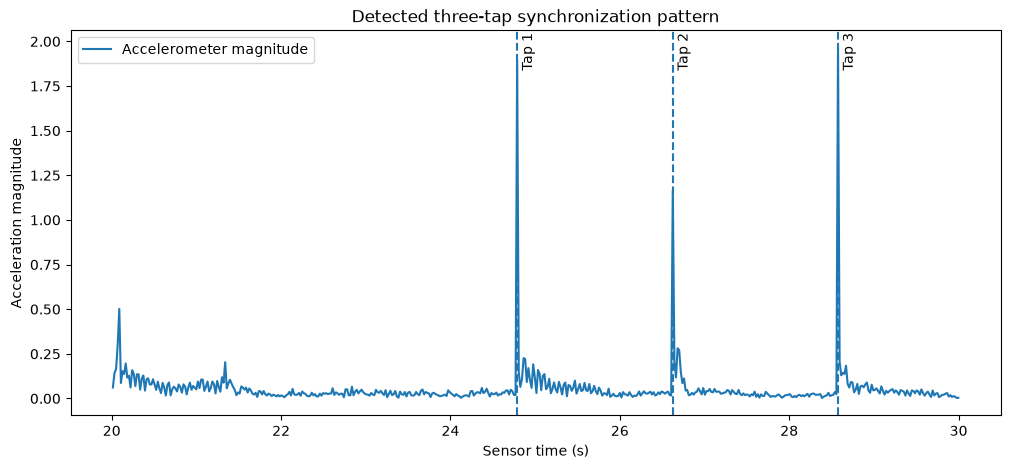

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    search["seconds_elapsed"],
    search["magnitude"],
    label="Accelerometer magnitude",
)

for i, t in enumerate(matched_peak_times, start=1):
    ax.axvline(t, linestyle="--")
    ax.text(t + 0.05, ax.get_ylim()[1] * 0.9, f"Tap {i}", rotation=90)

ax.set_xlabel("Sensor time (s)")
ax.set_ylabel("Acceleration magnitude")
ax.set_title("Detected three-tap synchronization pattern")
ax.legend()
plt.show()


### Your turn

Change `SYNC_SEARCH_START` or the peak `prominence`.

- When does the algorithm stop finding the correct three taps?
- Why can timing alone become ambiguous once walking starts?
- What other information could make an automatic sync detector more robust?


## 8. Shift **all** annotations onto the sensor clock

Once we have one clock shift, every annotation can be mapped onto the sensor timeline:

\[
t_{sensor} = t_{annotation-relative} + \Delta t
\]


In [41]:
annotations["sensor_time_s"] = (
    annotations["annotation_rel_s"] + TIME_SHIFT_S
)

display(
    annotations[
        ["text", "annotation_rel_s", "sensor_time_s"]
    ]
)


,text,annotation_rel_s,sensor_time_s
0,Taps,0.000,3.438032
1,Standing,21.379,24.817032
2,Standing,23.178,26.616032
3,Standing,25.118,28.556032
4,Walking,46.096,49.534032
5,Standing,86.790,90.228032
6,Walking,122.100,125.538032
7,StairsDown,151.093,154.531032
8,Walking,193.130,196.568032
9,Standing,268.839,272.277032


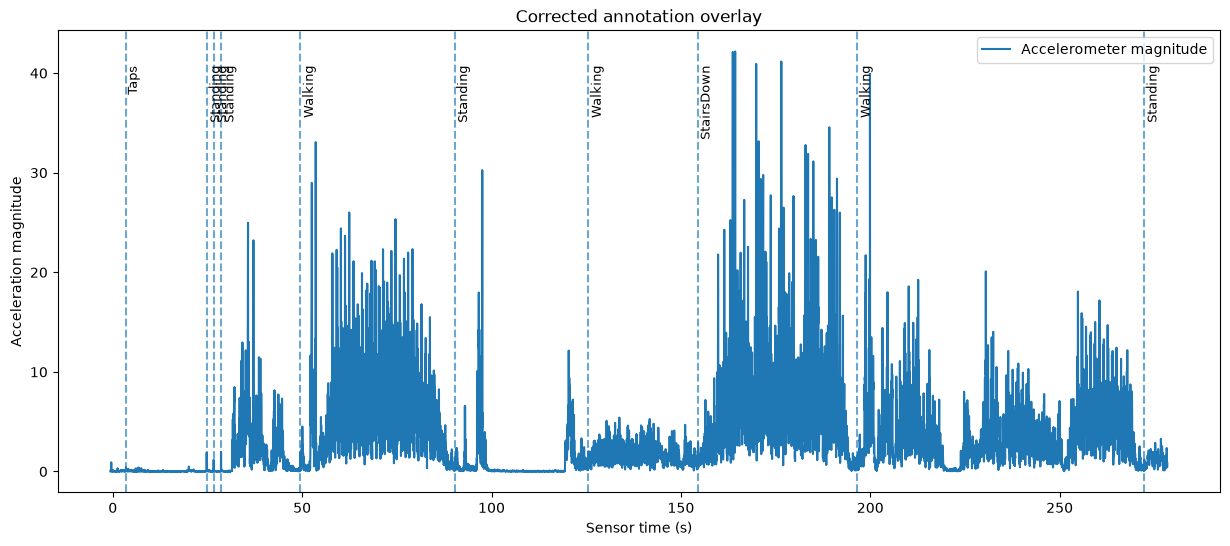

In [42]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    acc["seconds_elapsed"],
    acc["magnitude"],
    label="Accelerometer magnitude",
)

for i, row in annotations.iterrows():
    ax.axvline(row["sensor_time_s"], linestyle="--", alpha=0.65)
    ax.text(
        row["sensor_time_s"] + 0.4,
        ax.get_ylim()[1] * 0.92,
        row["text"],
        rotation=90,
        va="top",
        fontsize=9,
    )

ax.set_xlabel("Sensor time (s)")
ax.set_ylabel("Acceleration magnitude")
ax.set_title("Corrected annotation overlay")
ax.legend()
plt.show()


## 9. Turn annotation events into behavioral regions

For this recording:

- row 0 (`Taps`) is a sync marker,
- rows 1–3 are the three sync taps,
- row 4 onward contains the actual behavior transitions.

We will treat each behavioral annotation as meaning:

> **this activity begins here and continues until the next behavioral annotation**

The period before the first behavioral annotation remains `Unlabeled`.


In [17]:
FIRST_BEHAVIOR_ROW = 4

behavior_events = annotations.loc[FIRST_BEHAVIOR_ROW:, [
    "text", "sensor_time_s"
]].copy()

behavior_events = behavior_events.rename(columns={"text": "activity"})
behavior_events = behavior_events.reset_index(drop=True)

display(behavior_events)


,activity,sensor_time_s
0,Walking,49.534032
1,Standing,90.228032
2,Walking,125.538032
3,StairsDown,154.531032
4,Walking,196.568032
5,Standing,272.277032


In [44]:
def label_times_from_events(times, events):
    labels = np.full(len(times), "Unlabeled", dtype=object)

    for i, row in events.iterrows():
        start = row["sensor_time_s"]

        if i < len(events) - 1:
            stop = events.loc[i + 1, "sensor_time_s"]
        else:
            stop = np.inf

        mask = (times >= start) & (times < stop)
        labels[mask] = row["activity"]

    return labels


acc["activity"] = label_times_from_events(
    acc["seconds_elapsed"].to_numpy(),
    behavior_events,
)

acc[["seconds_elapsed", "magnitude", "activity"]].head()
print(acc["activity"].value_counts())
acc


activity
Walking       7668
Unlabeled     2645
StairsDown    2217
Standing      2186
Name: count, dtype: int64


,time,seconds_elapsed,z,y,x,magnitude,activity
0,1790858644682499000,-0.616501,0.000000,0.000000,0.000000,0.000000,Unlabeled
1,1790858644701443000,-0.597557,-0.030310,0.031099,0.046278,0.063462,Unlabeled
2,1790858644720387000,-0.578613,-0.023931,-0.023861,0.079543,0.086424,Unlabeled
3,1790858644739330800,-0.559669,-0.018126,-0.072766,0.081014,0.110393,Unlabeled
4,1790858644758274800,-0.540725,0.021524,-0.047287,0.033650,0.061901,Unlabeled
...,...,...,...,...,...,...,...
14711,1790858923636394200,278.337394,-0.004631,-0.607605,-0.079741,0.612832,Standing
14712,1790858923655339500,278.356340,-0.139915,-0.682214,-0.375050,0.790983,Standing
14713,1790858923674284500,278.375284,-0.237290,-0.771368,-0.520359,0.960254,Standing
14714,1790858923693229800,278.394230,-0.348431,-0.570122,-0.484209,0.825167,Standing


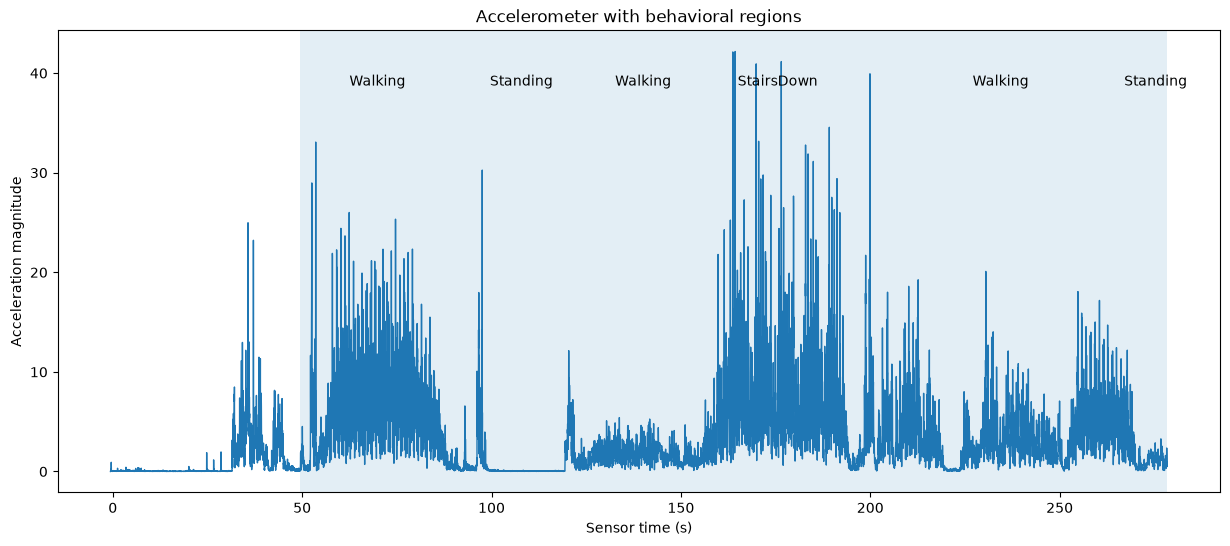

In [45]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(acc["seconds_elapsed"], acc["magnitude"], linewidth=1)

for i, row in behavior_events.iterrows():
    start = row["sensor_time_s"]
    stop = (
        behavior_events.loc[i + 1, "sensor_time_s"]
        if i < len(behavior_events) - 1
        else acc["seconds_elapsed"].max()
    )

    ax.axvspan(start, stop, alpha=0.12)
    ax.text(
        (start + stop) / 2,
        ax.get_ylim()[1] * 0.9,
        row["activity"],
        ha="center",
        va="top",
    )

ax.set_xlabel("Sensor time (s)")
ax.set_ylabel("Acceleration magnitude")
ax.set_title("Accelerometer with behavioral regions")
plt.show()


### Your turn

Inspect the region boundaries.

Do the annotation transitions line up perfectly with the physical transitions in the signal?

Probably not.

That is part of the science. Decide whether you want to:

- keep the raw annotation boundary,
- manually correct it,
- or discard a short transition margin around every boundary.

Later, a useful strategy may be to remove ±1–2 seconds around activity changes so that training windows do not contain ambiguous transitions.


## 10. Build a common 6-channel IMU time grid

Accelerometer and gyroscope samples are not timestamped at exactly the same instants.

A machine-learning table is easier to work with if both signals live on one regular time grid.

For teaching, we will interpolate onto a configurable grid.

> **Important:** this recording's observed IMU sampling rate is about 53 Hz. Setting `TARGET_FS = 100` gives us 200 samples per 2-second window, but the additional samples are interpolated. They do not contain new information.

You can change `TARGET_FS` to approximately the observed sampling rate instead.


In [46]:
TARGET_FS = 100.0   # Hz
DT = 1 / TARGET_FS

t_start = max(acc["seconds_elapsed"].min(), gyro["seconds_elapsed"].min())
t_stop = min(acc["seconds_elapsed"].max(), gyro["seconds_elapsed"].max())

time_grid = np.arange(t_start, t_stop, DT)

imu = pd.DataFrame({"time_s": time_grid})

for axis in ["x", "y", "z"]:
    imu[f"a{axis}"] = np.interp(
        time_grid,
        acc["seconds_elapsed"],
        acc[axis],
    )

    imu[f"g{axis}"] = np.interp(
        time_grid,
        gyro["seconds_elapsed"],
        gyro[axis],
    )

imu["activity"] = label_times_from_events(
    imu["time_s"].to_numpy(),
    behavior_events,
)

imu.head()


,time_s,ax,gx,ay,gy,az,gz,activity
0,-0.607029,0.023139,0.000153,0.015550,0.000916,-0.015155,0.002443,Unlabeled
1,-0.597029,0.047205,-0.000170,0.029567,0.000594,-0.030132,0.002443,Unlabeled
2,-0.587029,0.064765,-0.000424,0.000555,0.000408,-0.026764,0.002512,Unlabeled
3,-0.577029,0.079666,-0.000102,-0.027951,0.001375,-0.023445,0.003156,Unlabeled
4,-0.567029,0.080442,0.000153,-0.053766,0.002002,-0.020381,0.003665,Unlabeled


IMU table shape: (27903, 8)

Activity counts:


activity
Walking       14539
Unlabeled      5015
StairsDown     4204
Standing       4145
Name: count, dtype: int64

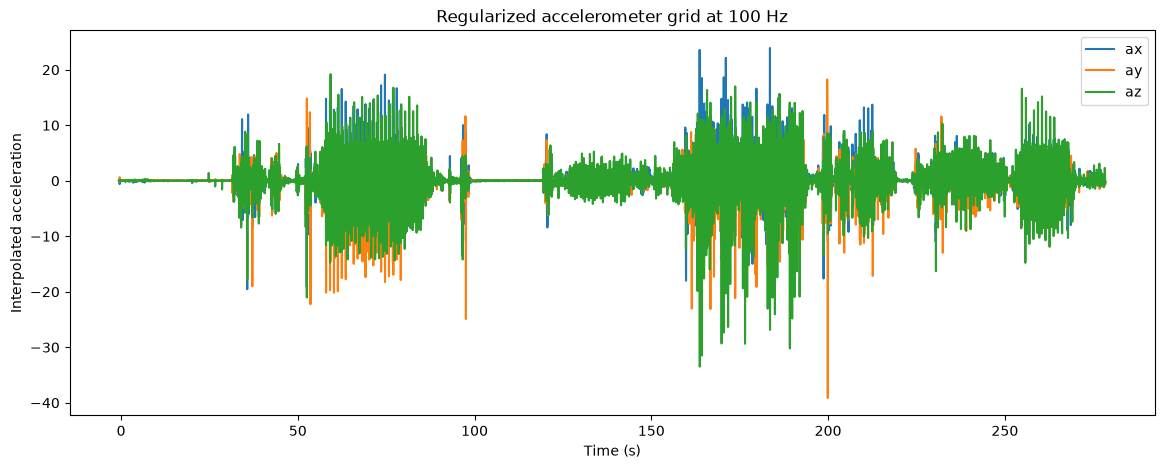

In [47]:
print("IMU table shape:", imu.shape)
print("\nActivity counts:")
display(imu["activity"].value_counts())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(imu["time_s"], imu["ax"], label="ax")
ax.plot(imu["time_s"], imu["ay"], label="ay")
ax.plot(imu["time_s"], imu["az"], label="az")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Interpolated acceleration")
ax.set_title(f"Regularized accelerometer grid at {TARGET_FS:.0f} Hz")
ax.legend()
plt.show()


### Your turn

Try `TARGET_FS = 50` and rebuild the table.

- How does the number of rows change?
- Does the plotted waveform materially change?
- For hand-engineered statistics like RMS and standard deviation, do you expect 50 Hz vs interpolated 100 Hz to matter much?
- For a CNN, why must all windows have the same number of samples?


## 11. Cut the signal into 2-second windows

Now each **window** becomes one machine-learning observation.

With:

- 2-second windows,
- 100 Hz target grid,
- 6 channels,

each example has shape:

`200 × 6`

We will use 50% overlap, so a new window begins every 1 second.

We also reject windows that contain more than one activity label.


In [49]:
CHANNELS = ["ax", "ay", "az", "gx", "gy", "gz"]

WINDOW_SECONDS = 2.0
STEP_SECONDS = 1.0

WINDOW_SAMPLES = int(WINDOW_SECONDS * TARGET_FS)
STEP_SAMPLES = int(STEP_SECONDS * TARGET_FS)

print("Samples per window:", WINDOW_SAMPLES)
print("Samples between window starts:", STEP_SAMPLES)


Samples per window: 200
Samples between window starts: 100


In [52]:
def make_windows(
    df,
    channels,
    window_samples,
    step_samples,
):
    X_windows = []
    y_windows = []
    starts = []
    stops = []

    values = df[channels].to_numpy()
    labels = df["activity"].to_numpy()
    times = df["time_s"].to_numpy()

    for start in range(
        0,
        len(df) - window_samples + 1,
        step_samples,
    ):
        stop = start + window_samples

        window_labels = labels[start:stop]
        unique_labels = np.unique(window_labels)

        # Reject transition windows and unlabeled windows.
        if len(unique_labels) != 1:
            continue

        label = unique_labels[0]

        if label == "Unlabeled":
            continue

        X_windows.append(values[start:stop])
        y_windows.append(label)
        starts.append(times[start])
        stops.append(times[stop - 1])

    return (
        np.asarray(X_windows),
        np.asarray(y_windows),
        np.asarray(starts),
        np.asarray(stops),
    )


X_windows, y_windows, window_starts, window_stops = make_windows(
    imu,
    CHANNELS,
    WINDOW_SAMPLES,
    STEP_SAMPLES,
)

print("X_windows shape:", X_windows.shape)
print("y_windows shape:", y_windows.shape)

display(pd.Series(y_windows).value_counts())
y_windows

X_windows shape: (217, 200, 6)
y_windows shape: (217,)


Walking       138
StairsDown     40
Standing       39
Name: count, dtype: int64

array(['Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking',
       'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking',
       'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking',
       'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking',
       'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking',
       'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking',
       'Walking', 'Walking', 'Standing', 'Standing', 'Standing',
       'Standing', 'Standing', 'Standing', 'Standing', 'Standing',
       'Standing', 'Standing', 'Standing', 'Standing', 'Standing',
       'Standing', 'Standing', 'Standing', 'Standing', 'Standing',
       'Standing', 'Standing', 'Standing', 'Standing', 'Standing',
       'Standing', 'Standing', 'Standing', 'Standing', 'Standing',
       'Standing', 'Standing', 'Standing', 'Standing', 'Standing',
       'Standing', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking',
       'Walking', 'Wa

### Your turn

Change one thing at a time:

1. use 1-second instead of 2-second windows,
2. remove overlap by setting `STEP_SECONDS = WINDOW_SECONDS`,
3. try 4-second windows.

For each version, ask:

- How many training examples do we get?
- How many cycles of walking might fit inside a window?
- How many windows are lost near activity transitions?
- Which choice seems biologically sensible?


## 12. Look at individual windows

A window is no longer "a long recording." It is now one candidate ML sample.

Let's plot a few.


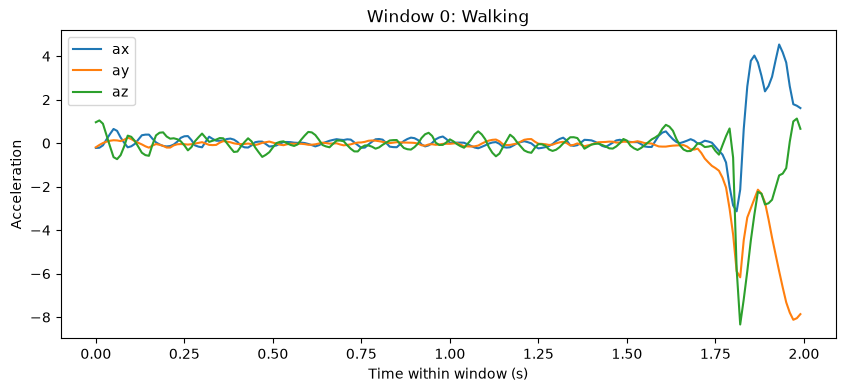

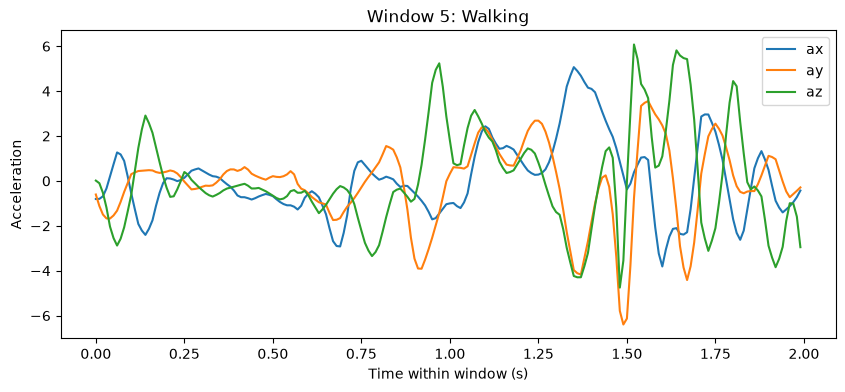

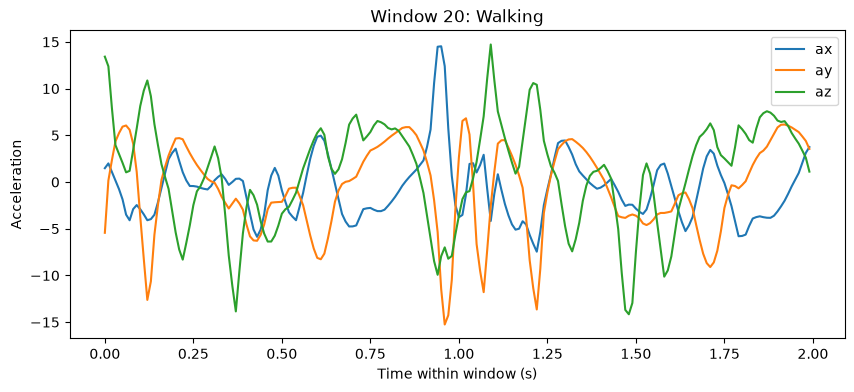

In [53]:
def plot_window(X_windows, y_windows, index, fs=TARGET_FS):
    t = np.arange(X_windows.shape[1]) / fs

    fig, ax = plt.subplots(figsize=(10, 4))

    for ch_i, ch_name in enumerate(CHANNELS[:3]):
        ax.plot(t, X_windows[index, :, ch_i], label=ch_name)

    ax.set_xlabel("Time within window (s)")
    ax.set_ylabel("Acceleration")
    ax.set_title(f"Window {index}: {y_windows[index]}")
    ax.legend()
    plt.show()


for idx in [0, min(5, len(X_windows)-1), min(20, len(X_windows)-1)]:
    plot_window(X_windows, y_windows, idx)


### Your turn

Find:

- one walking window,
- one standing window,
- one stairs-down window.

Do the waveforms look obviously different?

Also notice that walking windows can begin at arbitrary points in the gait cycle. This is one reason phase-insensitive features, or convolutional neural networks, can be useful.


## 13. Compute simple hand-engineered features

Before jumping to a CNN, let's make a classical ML representation.

For each of the six channels we will calculate:

- mean,
- standard deviation,
- RMS,
- minimum,
- maximum.

That gives:

`6 channels × 5 features = 30 features per window`


In [54]:
def hand_features(X_windows, channel_names=CHANNELS):
    rows = []
    feature_names = []

    if len(feature_names) == 0:
        for ch in channel_names:
            feature_names.extend([
                f"{ch}_mean",
                f"{ch}_std",
                f"{ch}_rms",
                f"{ch}_min",
                f"{ch}_max",
            ])

    for window in X_windows:
        row = []

        for ch_i in range(window.shape[1]):
            x = window[:, ch_i]

            row.extend([
                np.mean(x),
                np.std(x),
                np.sqrt(np.mean(x**2)),
                np.min(x),
                np.max(x),
            ])

        rows.append(row)

    return pd.DataFrame(rows, columns=feature_names)


features = hand_features(X_windows)

features["activity"] = y_windows
features["window_start_s"] = window_starts

display(features.head())
print("Feature table shape:", features.shape)


,ax_mean,ax_std,ax_rms,ax_min,ax_max,ay_mean,ay_std,ay_rms,ay_min,ay_max,...,gy_rms,gy_min,gy_max,gz_mean,gz_std,gz_rms,gz_min,gz_max,activity,window_start_s
0,0.221991,0.970403,0.995471,-3.135214,4.537491,-0.585394,1.661721,1.761818,-8.123856,0.254440,...,1.185799,-0.246224,4.105688,-0.226963,0.910352,0.938218,-5.409642,0.812280,Walking,50.392971
1,-0.481494,4.864769,4.888539,-19.112021,9.602949,-0.489522,3.116574,3.154785,-8.123856,14.819048,...,1.395627,-1.626737,4.105688,-1.128894,1.799190,2.124026,-6.623809,1.976301,Walking,51.392971
2,-0.686129,5.265306,5.309823,-19.112021,9.602949,-0.224025,4.146985,4.153031,-22.247761,14.819048,...,0.913684,-1.626737,3.470209,-1.048247,1.713293,2.008531,-6.623809,1.976301,Walking,52.392971
3,0.019986,2.528016,2.528095,-17.263657,5.494926,-0.302824,3.239715,3.253837,-22.247761,12.347395,...,0.957178,-1.448064,2.377129,-0.045377,0.682762,0.684268,-3.873665,1.605900,Walking,53.392971
4,-0.240699,1.266021,1.288699,-3.943923,3.228895,-0.178003,0.918969,0.936050,-3.912186,1.552738,...,1.188670,-1.085687,3.221095,-0.045549,0.394132,0.396755,-0.963345,0.702527,Walking,54.392971


Feature table shape: (217, 32)


### Your turn

Add **one** new feature that you think could help distinguish walking from standing.

Ideas:

- peak-to-peak range,
- median,
- interquartile range,
- acceleration magnitude RMS,
- dominant frequency,
- power in a locomotor frequency band.

Then explain *why* your feature might carry useful biological information.


## 14. Bridge into a scikit-learn Pipeline

Eventually we can wrap the feature calculation inside an sklearn transformer.

That lets the model pipeline say:

`raw 200×6 window → hand features → scaling → classifier`

We are **not** going to pretend that this one-person demo recording is enough to validate a classifier. Once all students contribute data, subject ID must be kept with every window so that cross-validation can hold out entire people.


In [55]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


class IMUFeatureExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rows = []

        for window in X:
            row = []

            for ch_i in range(window.shape[2] if window.ndim == 3 else window.shape[1]):
                pass

        # The implementation below is intentionally left for the next cell.
        return np.asarray(rows)


### Your turn

The stub above is deliberately incomplete.

Can you rewrite `transform()` so that it produces the same 30 hand-engineered features as `hand_features()`?

Hint: for a single `window`, its shape is:

`(samples, channels)`

so the channel loop should iterate over `range(window.shape[1])`.


In [27]:
class IMUFeatureExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rows = []

        for window in X:
            row = []

            for ch_i in range(window.shape[1]):
                x = window[:, ch_i]

                row.extend([
                    np.mean(x),
                    np.std(x),
                    np.sqrt(np.mean(x**2)),
                    np.min(x),
                    np.max(x),
                ])

            rows.append(row)

        return np.asarray(rows)


model = Pipeline([
    ("features", IMUFeatureExtractor()),
    ("scale", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000)),
])

model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a

## 15. Where this goes next

Once all 13 students contribute recordings, each window should carry a `subject_id`.

Then the development workflow becomes:

```text
raw Sensor Logger exports
        ↓
clock synchronization
        ↓
activity labels
        ↓
regular 6-channel IMU timeline
        ↓
2-second windows
        ↓
subject ID stays attached
        ↓
GroupKFold by subject
        ↓
hand features + Logistic Regression / RF / XGBoost
        ↓
compare with raw-window 1D CNN
        ↓
FINAL: evaluate once on the 3 vaulted students
```

The most important rule is:

> **Never randomly split overlapping windows across train and test.**

Adjacent windows from the same person are nearly twins. That would make performance look far better than true generalization to a new person.

### Final Your turn

Before collecting the class dataset, decide:

1. exact phone location,
2. exact activity list,
3. bout duration and number of repetitions,
4. annotation protocol,
5. sync-tap protocol,
6. whether to discard transition margins,
7. which three subjects remain completely vaulted for final testing.


In [28]:
np.savez_compressed(
    "imu_windows.npz",
    X_windows=X_windows.astype(np.float32),
    y_windows=y_windows.astype(str),
    window_starts=window_starts.astype(np.float64),
    window_stops=window_stops.astype(np.float64),
    channel_names=np.array(CHANNELS),
    sample_rate_hz=np.array(TARGET_FS),
)